**Цель ноутбука:**
1. Сравнить модели классификации
2. Оценить качество моделей
3. Проанализировать ROC-кривые
4. Исследовать устойчивость моделей
5. Выбрать лучшую модель

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent / 'src'
sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    load_data,
    split_data,
    build_preprocessor
)

from modeling import (
    compare_models,
    cross_validate_models,
    get_feature_importance,
    plot_roc_curves,
    plot_confusion_matrix
)

sns.set_style("whitegrid")

In [3]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df)

In [4]:
preprocessor = build_preprocessor()

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [5]:
results_df, trained_models, roc_data = compare_models(
    X_train_proc,
    X_test_proc,
    y_train,
    y_test,
    ["logistic", "tree", "rf"]
)

results_df.sort_values(
    "roc_auc",
    ascending=False
)

logistic best params: {'C': 0.1, 'solver': 'liblinear'}
tree best params: {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
rf best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}


,model,accuracy,precision,recall,f1,roc_auc
2,rf,0.742556,0.720969,0.791342,0.754518,0.817933
1,tree,0.735696,0.714580,0.784835,0.748062,0.812930
0,logistic,0.735413,0.726703,0.754562,0.740371,0.812208


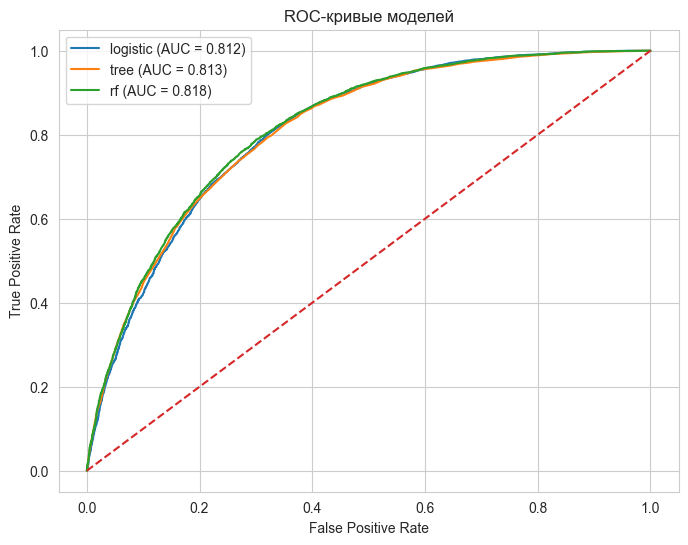

In [6]:
plot_roc_curves(roc_data)

In [7]:
cv_df = cross_validate_models(
    X_train_proc,
    y_train,
    trained_models
)

cv_df.sort_values(
    "cv_mean",
    ascending=False
)

,model,cv_mean,cv_std
2,rf,0.817231,0.003627
0,logistic,0.814658,0.003405
1,tree,0.811828,0.003537


In [8]:
best_name = results_df.sort_values(
    "roc_auc",
    ascending=False
).iloc[0]["model"]

best_model = trained_models[best_name]

print("Лучшая модель:", best_name)

Лучшая модель: rf


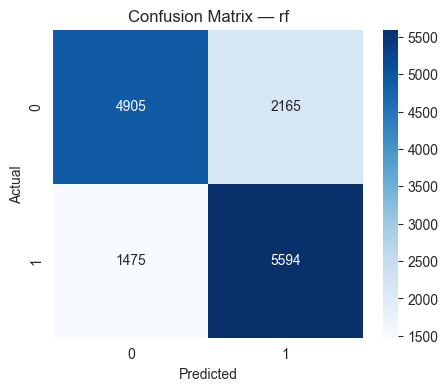

In [9]:
best_pred = best_model.predict(X_test_proc)

plot_confusion_matrix(
    y_test,
    best_pred,
    best_name
)

In [10]:
importance = get_feature_importance(
    best_model,
    best_name
)

importance

,feature,label,importance
1,BMI,ИМТ,0.310077
3,HighBP,Высокое кровяное давление,0.233012
0,GenHlth,Общее состояние здоровья,0.199664
2,Age,Возрастная группа,0.146484
6,DiffWalk,Трудности при ходьбе,0.062585
5,HeartDiseaseorAttack,Болезни сердца/инфаркт,0.038193
4,PhysActivity,Физическая активность,0.009986


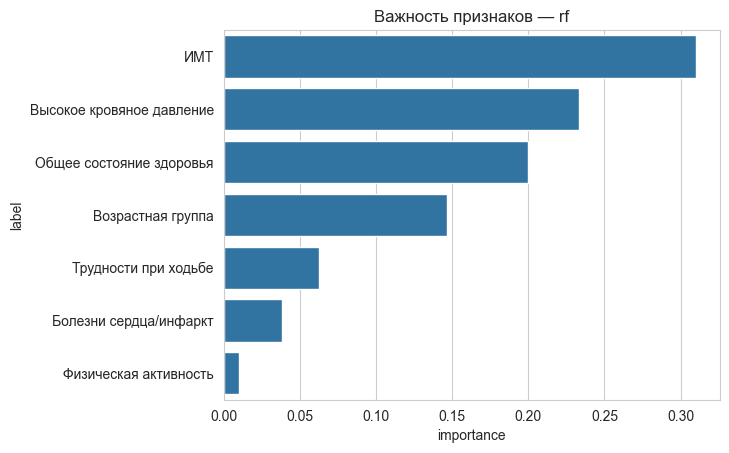

In [11]:
sns.barplot(
    data=importance,
    x="importance",
    y="label"
)

plt.title(f"Важность признаков — {best_name}")

plt.show()

**Выводы:**

1. Все модели показали хороший уровень качества.

2. Logistic Regression:
   + высокая интерпретируемость
   + простота анализа
   - немного уступает по качеству

3. Decision Tree:
   + умеет находить нелинейные зависимости
   - менее устойчива

4. Random Forest:
   + лучший ROC-AUC
   + устойчивость к шуму
   + лучший общий баланс

5. Наиболее значимые признаки:
   - Общее состояние здоровья
   - BMI
   - Возраст
   - Высокое давление

6. Для production-версии проекта выбрана Random Forest.

**Финальный вывод:**

1. Все модели показали близкий уровень качества.
2. Лучший результат достигнут Random Forest.
3. Для production-версии проекта выбрана Random Forest.